In [1]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import matplotlib.pyplot as plt
from scripts.hamiltonian import *

In [7]:
t = 1
mu = -2. * t
gap_p= cp.array([0.1, 0.1])
gap_0 = 0.1
X,Y = 25,25
lattice = Lattice(X, Y, pbc_x=False, pbc_y=False)
H = Hamiltonian(lattice)
block = cp.zeros((4, 4), dtype=cp.complex128)
for i in range(lattice.num_sites):
    block[:,:]=0
    block[:2, :2] = -mu * s0
    block[2:, 2:] = mu * s0
    block[:2, 2:] = -1j * gap_0 * s2
    block[2:, :2] = (-1j * gap_0 * s2).conj().T
    H.set_block(i,i, block)
    H.set_gap(gap_0,i)
    
for i, j in lattice.edges:
    block[:,:]=0
    block[0:2, 0:2] = -t * s0
    block[2:4, 2:4] = t * s0

    # gap_ij = unconventional_gap(lattice.get_disp(i,j),gap_p = gap_p)
    # block[0:2, 2:4] = gap_ij
    # block[2:4, 0:2] = -gap_ij.T.conj()

    H.set_block(i,j, block)


energies = cp.linspace(-3,3,500) 
dos = H.dos(energies, eta=0.05, drop_matrix=False)

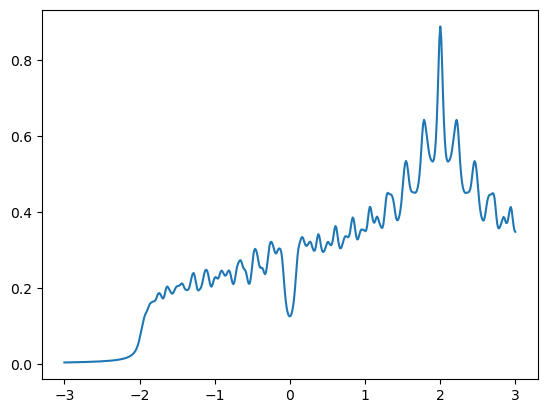

In [8]:
plt.plot(cp.asnumpy(energies),cp.asnumpy(dos))

In [9]:
gap,corr = H.bdg_self_consistency(2,1e-6, max_iter=100, with_corr=True)

Converged after 31 iterations.


d:\miniconda3\envs\master-venv\lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
d:\miniconda3\envs\master-venv\lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


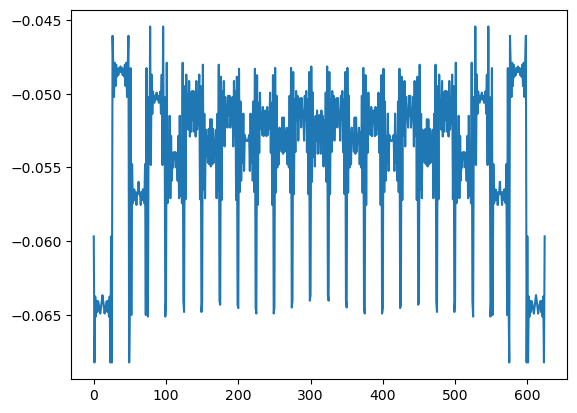

In [10]:
plt.plot(cp.asnumpy(corr))